<a href="https://colab.research.google.com/github/LeinMS/hse-image-captioning/blob/BLIP/BLIP%2BResNet_Cubes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from PIL import Image
from transformers import AutoModelForVision2Seq, AutoProcessor
import time, requests, torch
import torch.nn as nn

In [2]:
#GET WEGHTS AND DATASET FROM MY GOOGLE.DRIVE
try:
    import gdown
except ImportError:
    %pip install gdown -q

print(f"Downloading...")
# Download the file using gdown
!gdown --id {'15DrB_xj2xZEvVfWU3B2zdcUZZYSnSH0g'} -O {'dataset.zip'}
!gdown --id {'14z2ZirZdRUTunH_PW53xBZlmE-lQ7h4P'} -O {'model_resnet.pth'}
!gdown --id {'1bdjfHPKz8ETxSjEziZLdcl5zu8zVvUl0'} -O {'caption+resnet.zip'}

print(f"Unzipping...")
# Unzip the downloaded file
!unzip -o -q {'dataset.zip'}
!unzip -o -q {'caption+resnet.zip'}
print("Download and unzipping complete.")

Downloading...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=15DrB_xj2xZEvVfWU3B2zdcUZZYSnSH0g
From (redirected): https://drive.google.com/uc?id=15DrB_xj2xZEvVfWU3B2zdcUZZYSnSH0g&confirm=t&uuid=3ef63f84-598a-412a-bab6-6291766f4808
To: /content/dataset.zip
100% 156M/156M [00:02<00:00, 73.4MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14z2ZirZdRUTunH_PW53xBZlmE-lQ7h4P
From (redirected): https://drive.google.com/uc?id=14z2ZirZdRUTunH_PW53xBZlmE-lQ7h4P&confirm=t&uuid=46e694cd-4117-445c-b840-6d6c8a94a649
To: /content/

In [3]:
class ResNetPatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = torch.hub.load('pytorch/vision', 'resnet18')
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4,
        )
        self.proj = nn.Conv2d(512, 768, 1, 1, 0)
        self.fc = nn.Linear(768, 10)
        self._first_conv = backbone.conv1

    @property
    def weight(self):
        return self._first_conv.weight

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.proj(x)
        # print(x.shape)
        x = x.flatten(2)

        return x

def replace_blip_patch_with_resnet(blip_model):
    hidden_size = blip_model.config.vision_config.hidden_size
    resnet_patch = ResNetPatchEmbedding()
    del resnet_patch.fc
    resnet_patch.load_state_dict(torch.load('model_resnet.pth', weights_only=True, map_location=torch.device('cpu')), strict=False)

    if hasattr(blip_model.vision_model, "embeddings") and \
            hasattr(blip_model.vision_model.embeddings, "patch_embedding"):
        blip_model.vision_model.embeddings.patch_embedding = resnet_patch
    elif hasattr(blip_model.vision_model, "patch_embed"):
        blip_model.vision_model.patch_embed = resnet_patch
    else:
        raise RuntimeError("Cannot find patch embedding module in BLIP vision_model")

In [7]:
processor = AutoProcessor.from_pretrained('Salesforce/blip-image-captioning-base')
model = AutoModelForVision2Seq.from_pretrained('caption+resnet (copy)')

model.eval()
replace_blip_patch_with_resnet(model)
print(model)


Using cache found in /root/.cache/torch/hub/pytorch_vision_main


BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): ResNetPatchEmbedding(
        (stem): Sequential(
          (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (4): Sequential(
            (0): BasicBlock(
              (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (relu): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

1.6511900424957275


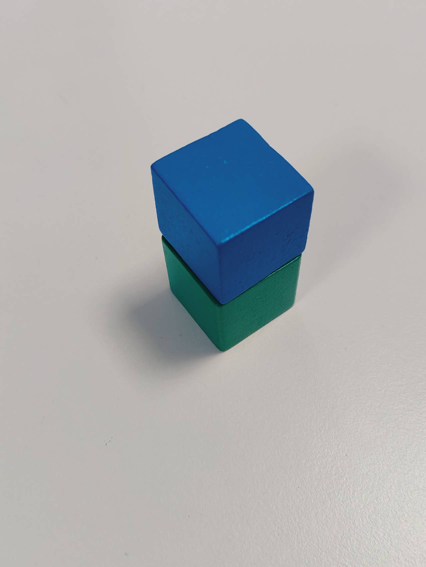

['a blue cube on top of a green cube']


In [13]:
image = Image.open("/content/dataset/image_test/BlueUp1.jpg")

time_start = time.time()
processed = processor(images=image, padding="max_length", return_tensors="pt")
generated_output = model.generate(pixel_values=processed['pixel_values'], max_new_tokens=64)

print(time.time() - time_start)
x, y = image.size
scale = 1 if ((x <= 500) & (y <= 500)) else (x // 500 if x > y else y // 500)
display(image.resize((x//scale, y//scale)))
print(processor.batch_decode(generated_output, skip_special_tokens=True))